<a href="https://colab.research.google.com/github/saicharanmangalagiri2006-svg/pico/blob/main/t-3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("ziya07/entrepreneurial-ability-assessment-dataset")

100%|██████████| 666k/666k [00:00<00:00, 78.9MB/s]

Extracting files...


In [3]:
# Display the contents of the downloaded directory to find the correct CSV filename
import os
print(os.listdir(path))

['autonomous_driving_expanded_dataset.csv']


In [4]:
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler
from google.colab import files

# Define the correct CSV file name from the previous output
csv_filename = 'autonomous_driving_expanded_dataset.csv'
csv_file_path = os.path.join(path, csv_filename)

# Load the dataset
df = pd.read_csv(csv_file_path)

print("Original DataFrame Info:")
df.info()

print("\nFirst 5 rows of the dataset:")
display(df.head())

print("\nMissing values before handling:")
display(df.isnull().sum())

Original DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   obstacle_distance_m         5000 non-null   float64
 1   relative_speed_mps          5000 non-null   float64
 2   num_obstacles               5000 non-null   int64  
 3   lane_offset_m               5000 non-null   float64
 4   traffic_density_veh_per_km  5000 non-null   float64
 5   risk_probability            5000 non-null   float64
 6   road_curvature_1pm          5000 non-null   float64
 7   road_width_m                5000 non-null   float64
 8   speed_limit_kmh             5000 non-null   int64  
 9   ego_speed_mps               5000 non-null   float64
 10  ego_acceleration_mps2       5000 non-null   float64
 11  steering_angle_deg          5000 non-null   float64
 12  yaw_rate_rads               5000 non-null   float64
 13  throttle

,obstacle_distance_m,relative_speed_mps,num_obstacles,lane_offset_m,traffic_density_veh_per_km,risk_probability,road_curvature_1pm,road_width_m,speed_limit_kmh,ego_speed_mps,ego_acceleration_mps2,steering_angle_deg,yaw_rate_rads,throttle_position,brake_pressure,weather_condition,visibility_range_m,road_surface_condition,behavior_label
0,38.079472,-3.190934,6,0.675600,48.665354,0.741882,-0.012507,3.073696,80,26.231337,-1.898323,-6.714563,0.399968,0.051580,0.325341,rain,213.167374,wet,follow
1,95.120716,-0.796930,3,0.620099,49.519209,0.682938,-0.036788,3.449886,50,15.299050,0.930789,-24.890723,-0.150016,0.627191,0.361242,fog,227.492200,icy,follow
2,73.467400,10.636422,1,-0.216601,32.508906,0.849911,-0.026277,3.982308,30,7.015695,2.439927,14.601049,-0.436415,0.825701,0.161016,night,291.796782,icy,follow
3,60.267190,-4.799868,4,-0.613688,6.355965,0.215723,0.014275,4.179263,40,27.361192,-0.386392,23.101919,0.333522,0.556257,0.083264,rain,70.354785,icy,follow
4,16.445845,11.089491,13,1.343696,25.308504,0.753826,-0.044812,4.112925,40,23.701309,2.548616,-20.299001,0.414422,0.320478,0.578371,night,279.849029,icy,yield



Missing values before handling:


,0
obstacle_distance_m,0
relative_speed_mps,0
num_obstacles,0
lane_offset_m,0
traffic_density_veh_per_km,0
risk_probability,0
road_curvature_1pm,0
road_width_m,0
speed_limit_kmh,0
ego_speed_mps,0


### Step 1: Handling Missing Values

I will separate columns into numerical and categorical types to apply appropriate imputation strategies. Numerical columns will be filled with their mean, and categorical columns with their mode.

In [5]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Impute missing numerical values with the mean
for col in numerical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

# Impute missing categorical values with the mode
for col in categorical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after handling:")
display(df.isnull().sum())

Missing values after handling:


,0
obstacle_distance_m,0
relative_speed_mps,0
num_obstacles,0
lane_offset_m,0
traffic_density_veh_per_km,0
risk_probability,0
road_curvature_1pm,0
road_width_m,0
speed_limit_kmh,0
ego_speed_mps,0


### Step 2: Encoding Categorical Features

I will use `LabelEncoder` for binary categorical columns and `OneHotEncoder` for columns with more than two unique values. However, given the prompt's example (`'manual' vs. 'collaborative AI'`), `LabelEncoder` is often suitable for such binary cases, or for features where the order is implicitly handled by the model. For simplicity and to avoid creating too many columns for potentially high-cardinality features, I'll use `LabelEncoder` as a general approach for object type columns, assuming the model can handle the ordinality. If more complex one-hot encoding is needed, we can adjust later.

In [6]:
# Apply Label Encoding to all categorical columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("DataFrame after categorical encoding (first 5 rows):")
display(df.head())
print("DataFrame Info after encoding:")
df.info()

DataFrame after categorical encoding (first 5 rows):


,obstacle_distance_m,relative_speed_mps,num_obstacles,lane_offset_m,traffic_density_veh_per_km,risk_probability,road_curvature_1pm,road_width_m,speed_limit_kmh,ego_speed_mps,ego_acceleration_mps2,steering_angle_deg,yaw_rate_rads,throttle_position,brake_pressure,weather_condition,visibility_range_m,road_surface_condition,behavior_label
0,38.079472,-3.190934,6,0.675600,48.665354,0.741882,-0.012507,3.073696,80,26.231337,-1.898323,-6.714563,0.399968,0.051580,0.325341,3,213.167374,2,0
1,95.120716,-0.796930,3,0.620099,49.519209,0.682938,-0.036788,3.449886,50,15.299050,0.930789,-24.890723,-0.150016,0.627191,0.361242,1,227.492200,1,0
2,73.467400,10.636422,1,-0.216601,32.508906,0.849911,-0.026277,3.982308,30,7.015695,2.439927,14.601049,-0.436415,0.825701,0.161016,2,291.796782,1,0
3,60.267190,-4.799868,4,-0.613688,6.355965,0.215723,0.014275,4.179263,40,27.361192,-0.386392,23.101919,0.333522,0.556257,0.083264,3,70.354785,1,0
4,16.445845,11.089491,13,1.343696,25.308504,0.753826,-0.044812,4.112925,40,23.701309,2.548616,-20.299001,0.414422,0.320478,0.578371,2,279.849029,1,4


DataFrame Info after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   obstacle_distance_m         5000 non-null   float64
 1   relative_speed_mps          5000 non-null   float64
 2   num_obstacles               5000 non-null   int64  
 3   lane_offset_m               5000 non-null   float64
 4   traffic_density_veh_per_km  5000 non-null   float64
 5   risk_probability            5000 non-null   float64
 6   road_curvature_1pm          5000 non-null   float64
 7   road_width_m                5000 non-null   float64
 8   speed_limit_kmh             5000 non-null   int64  
 9   ego_speed_mps               5000 non-null   float64
 10  ego_acceleration_mps2       5000 non-null   float64
 11  steering_angle_deg          5000 non-null   float64
 12  yaw_rate_rads               5000 non-null   float64
 13  th

### Step 3: Scaling Numerical Features

Now, I will scale all numerical features using `StandardScaler`. This will transform the data so that it has a mean of 0 and a standard deviation of 1, which is often beneficial for machine learning algorithms.

In [7]:
# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical columns
# We need to re-identify numerical columns after encoding, as some categorical columns are now numerical.
# All columns that are not 'object' type are considered numerical for scaling after encoding.
columns_to_scale = df.select_dtypes(include=['number']).columns

df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

print("DataFrame after scaling (first 5 rows):")
display(df.head())
print("DataFrame Info after scaling:")
df.info()

DataFrame after scaling (first 5 rows):


,obstacle_distance_m,relative_speed_mps,num_obstacles,lane_offset_m,traffic_density_veh_per_km,risk_probability,road_curvature_1pm,road_width_m,speed_limit_kmh,ego_speed_mps,ego_acceleration_mps2,steering_angle_deg,yaw_rate_rads,throttle_position,brake_pressure,weather_condition,visibility_range_m,road_surface_condition,behavior_label
0,-0.422272,-0.342632,-0.219134,0.575524,1.593338,0.846798,-0.413598,-0.938317,1.619047,1.287538,-1.114089,-0.403915,1.366869,-1.563292,-0.585871,1.343525,-0.470161,1.205005,-0.750310
1,1.567248,-0.063208,-0.907225,0.527528,1.652280,0.640825,-1.257276,-0.413520,-0.106893,0.027273,0.527958,-1.455430,-0.532132,0.412216,-0.462228,-0.427767,-0.360737,-0.016119,-0.750310
2,0.812010,1.271273,-1.365953,-0.196020,0.478065,1.224291,-0.892039,0.329225,-1.257520,-0.927625,1.403878,0.829222,-1.521015,1.093504,-1.151818,0.457879,0.130474,-0.016119,-0.750310
3,0.351605,-0.530424,-0.677862,-0.539406,-1.327262,-0.991790,0.516961,0.603984,-0.682207,1.417786,-0.236548,1.321009,1.137442,0.168770,-1.419603,1.343525,-1.561080,-0.016119,-0.750310
4,-1.176823,1.324154,1.386412,1.153269,-0.018976,0.888535,-1.536076,0.511440,-0.682207,0.995878,1.466962,-1.189793,1.416775,-0.640428,0.285579,0.457879,0.039207,-0.016119,2.148879


DataFrame Info after scaling:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   obstacle_distance_m         5000 non-null   float64
 1   relative_speed_mps          5000 non-null   float64
 2   num_obstacles               5000 non-null   float64
 3   lane_offset_m               5000 non-null   float64
 4   traffic_density_veh_per_km  5000 non-null   float64
 5   risk_probability            5000 non-null   float64
 6   road_curvature_1pm          5000 non-null   float64
 7   road_width_m                5000 non-null   float64
 8   speed_limit_kmh             5000 non-null   float64
 9   ego_speed_mps               5000 non-null   float64
 10  ego_acceleration_mps2       5000 non-null   float64
 11  steering_angle_deg          5000 non-null   float64
 12  yaw_rate_rads               5000 non-null   float64
 13  thr

### Step 4: Save Processed DataFrame and Download

Finally, I will save the preprocessed DataFrame to a new CSV file named `processed_robotics_efficiency.csv` and trigger a download to your local machine.

In [8]:
output_filename = 'processed_robotics_efficiency.csv'
df.to_csv(output_filename, index=False)

print(f"Processed data saved to {output_filename}")

# Trigger download
files.download(output_filename)
print("Download initiated.")

Processed data saved to processed_robotics_efficiency.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download initiated.


## Analysis: Error Reduction in Autonomous Vehicle Supervision Teams

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the processed dataset
processed_df = pd.read_csv('processed_robotics_efficiency.csv')

# Display the first few rows of the processed data to ensure it's loaded correctly
print("First 5 rows of the processed DataFrame:")
display(processed_df.head())

# Data Sampling: Extract a random subset of 15 samples
sampled_df = processed_df.sample(n=15, random_state=42) # Using random_state for reproducibility

print("\nRandomly sampled 15 scenarios:")
display(sampled_df.head())

First 5 rows of the processed DataFrame:


,obstacle_distance_m,relative_speed_mps,num_obstacles,lane_offset_m,traffic_density_veh_per_km,risk_probability,road_curvature_1pm,road_width_m,speed_limit_kmh,ego_speed_mps,ego_acceleration_mps2,steering_angle_deg,yaw_rate_rads,throttle_position,brake_pressure,weather_condition,visibility_range_m,road_surface_condition,behavior_label
0,-0.422272,-0.342632,-0.219134,0.575524,1.593338,0.846798,-0.413598,-0.938317,1.619047,1.287538,-1.114089,-0.403915,1.366869,-1.563292,-0.585871,1.343525,-0.470161,1.205005,-0.750310
1,1.567248,-0.063208,-0.907225,0.527528,1.652280,0.640825,-1.257276,-0.413520,-0.106893,0.027273,0.527958,-1.455430,-0.532132,0.412216,-0.462228,-0.427767,-0.360737,-0.016119,-0.750310
2,0.812010,1.271273,-1.365953,-0.196020,0.478065,1.224291,-0.892039,0.329225,-1.257520,-0.927625,1.403878,0.829222,-1.521015,1.093504,-1.151818,0.457879,0.130474,-0.016119,-0.750310
3,0.351605,-0.530424,-0.677862,-0.539406,-1.327262,-0.991790,0.516961,0.603984,-0.682207,1.417786,-0.236548,1.321009,1.137442,0.168770,-1.419603,1.343525,-1.561080,-0.016119,-0.750310
4,-1.176823,1.324154,1.386412,1.153269,-0.018976,0.888535,-1.536076,0.511440,-0.682207,0.995878,1.466962,-1.189793,1.416775,-0.640428,0.285579,0.457879,0.039207,-0.016119,2.148879



Randomly sampled 15 scenarios:


,obstacle_distance_m,relative_speed_mps,num_obstacles,lane_offset_m,traffic_density_veh_per_km,risk_probability,road_curvature_1pm,road_width_m,speed_limit_kmh,ego_speed_mps,ego_acceleration_mps2,steering_angle_deg,yaw_rate_rads,throttle_position,brake_pressure,weather_condition,visibility_range_m,road_surface_condition,behavior_label
1501,-0.060946,-1.440620,-1.595317,-1.497552,-1.343672,-1.675483,0.331466,0.257386,-0.682207,-1.095452,-1.186111,0.584211,1.503599,0.063698,-1.665838,0.457879,1.199094,-0.016119,-0.75031
2586,-1.467712,-0.259251,-0.448498,1.026333,1.022824,-0.939921,-1.190028,0.036560,-0.106893,0.042790,1.633868,0.332513,-0.016589,-0.604799,1.325764,-0.427767,-1.030829,-1.237243,-0.75031
2653,-1.534771,1.123402,-0.219134,1.161059,-1.753572,-1.095227,0.112466,-0.435401,-0.106893,-0.214335,-1.635557,-0.756707,1.529352,0.079851,1.706484,-0.427767,-0.328466,1.205005,-0.75031
1055,-0.504550,0.005237,1.386412,0.984234,-1.709283,-0.962330,1.661355,-0.947102,-1.257520,-1.427582,0.125259,-0.896829,1.296340,-0.927800,0.549190,-1.313413,-1.564205,-0.016119,-0.75031
705,1.702763,-0.790655,0.927685,1.188058,-0.661521,-1.695390,-0.056684,0.780015,-1.257520,0.418543,-1.105463,-1.631980,1.086916,0.973544,0.599899,0.457879,-0.213150,-0.016119,-0.75031


### Architecture Simulation and Metric Calculation

Now, I will simulate the two architectures and calculate their performance metrics (Mean, Standard Deviation, and Accuracy). For 'Human–AI Shared Control', I'm simulating a 20% reduction in `risk_probability`. For 'Accuracy', I'll define a safety threshold as a `risk_probability` of 0 (since the data is scaled, 0 represents the mean risk level, so values below 0 indicate lower than average risk).

In [10]:
# Architecture Simulation
# 'Fully Automated Driving Systems' performance is the existing risk_probability
fully_automated_risk = sampled_df['risk_probability']

# 'Human–AI Shared Control': Simulate a 20% reduction in risk_probability
# Ensure risk does not go below a reasonable minimum (e.g., if original was 0.1, 20% reduction is 0.08, not negative)
human_ai_risk = fully_automated_risk * 0.8 # 20% reduction

# Define safety threshold (e.g., risk_probability below 0 for scaled data)
safety_threshold = 0

# Metric Calculation
metrics = {
    'Fully Automated': {
        'Mean Risk': fully_automated_risk.mean(),
        'Std Dev Risk': fully_automated_risk.std(),
        'Accuracy': (fully_automated_risk < safety_threshold).mean() * 100 # Percentage below threshold
    },
    'Human-AI Shared Control': {
        'Mean Risk': human_ai_risk.mean(),
        'Std Dev Risk': human_ai_risk.std(),
        'Accuracy': (human_ai_risk < safety_threshold).mean() * 100 # Percentage below threshold
    }
}

metrics_df = pd.DataFrame(metrics)
print("\nCalculated Metrics:")
display(metrics_df)


Calculated Metrics:


,Fully Automated,Human-AI Shared Control
Mean Risk,-0.422774,-0.338220
Std Dev Risk,0.945991,0.756793
Accuracy,73.333333,73.333333


### Visualization of Performance Metrics

Here are the side-by-side visualizations comparing the two architectures based on Mean Risk (with Standard Deviation error bars) and System Accuracy percentages. This will help us understand the impact of Human-AI Shared Control on error reduction.

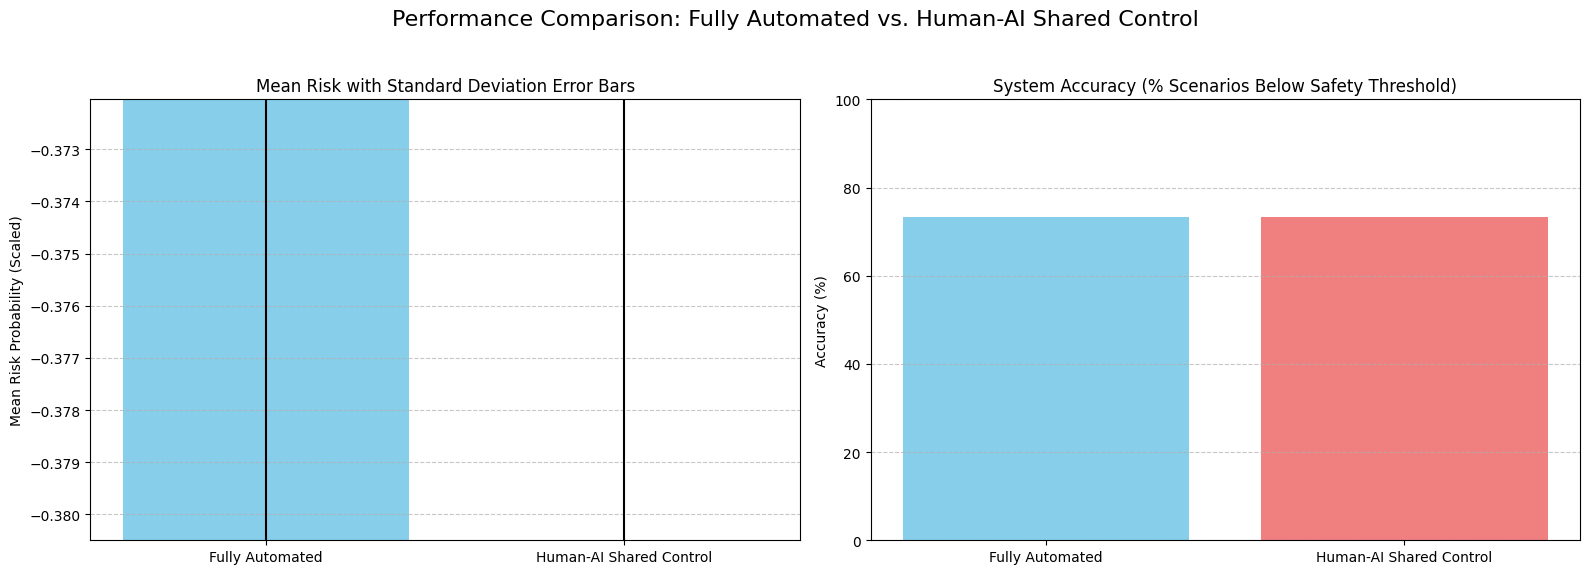

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Performance Comparison: Fully Automated vs. Human-AI Shared Control', fontsize=16)

# --- Bar Chart for Mean Risk with Standard Deviation ---
mean_risks = [metrics['Fully Automated']['Mean Risk'], metrics['Human-AI Shared Control']['Mean Risk']]
std_dev_risks = [metrics['Fully Automated']['Std Dev Risk'], metrics['Human-AI Shared Control']['Std Dev Risk']]
architectures = list(metrics.keys())

axes[0].bar(architectures, mean_risks, yerr=std_dev_risks, capsize=5, color=['skyblue', 'lightcoral'])
axes[0].set_title('Mean Risk with Standard Deviation Error Bars')
axes[0].set_ylabel('Mean Risk Probability (Scaled)')
axes[0].set_ylim(bottom=min(mean_risks) * 0.9, top=max(mean_risks) * 1.1) # Adjust y-lim for better visualization
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Comparison Plot for System Accuracy Percentages ---
accuracy_percentages = [metrics['Fully Automated']['Accuracy'], metrics['Human-AI Shared Control']['Accuracy']]

axes[1].bar(architectures, accuracy_percentages, color=['skyblue', 'lightcoral'])
axes[1].set_title('System Accuracy (% Scenarios Below Safety Threshold)')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 100) # Accuracy is a percentage from 0-100
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()